In [106]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)         # show all columns
pd.set_option('display.expand_frame_repr', False)  # disable wrapping


In [107]:
df = pd.read_csv('train.csv')
print(df.head())


   PassengerId  Survived  Pclass                                               Name     Sex   Age  SibSp  Parch            Ticket     Fare Cabin Embarked
0            1         0       3                            Braund, Mr. Owen Harris    male  22.0      1      0         A/5 21171   7.2500   NaN        S
1            2         1       1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1      0          PC 17599  71.2833   C85        C
2            3         1       3                             Heikkinen, Miss. Laina  female  26.0      0      0  STON/O2. 3101282   7.9250   NaN        S
3            4         1       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1      0            113803  53.1000  C123        S
4            5         0       3                           Allen, Mr. William Henry    male  35.0      0      0            373450   8.0500   NaN        S


<function matplotlib.pyplot.show(close=None, block=None)>

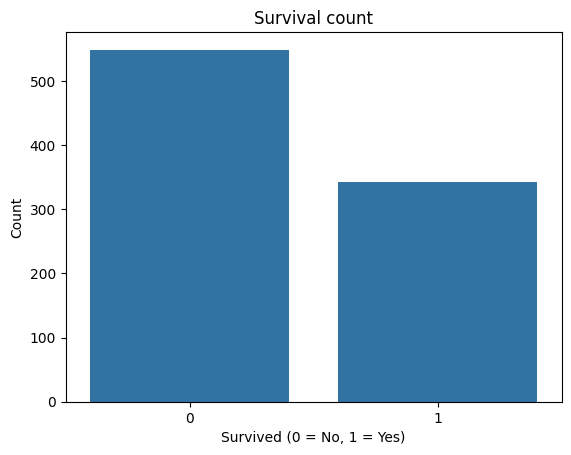

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Survived', data=df)
plt.title('Survival count')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show

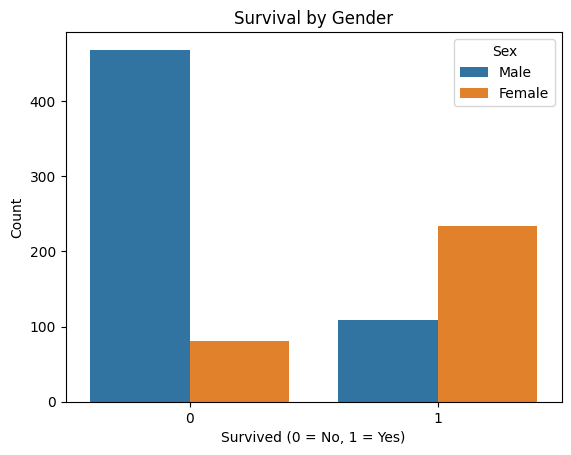

In [82]:
sns.countplot(x='Survived', hue='Sex', data=df)
plt.title('Survival by Gender')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.legend(title='Sex', labels=['Male', 'Female'])
plt.show()

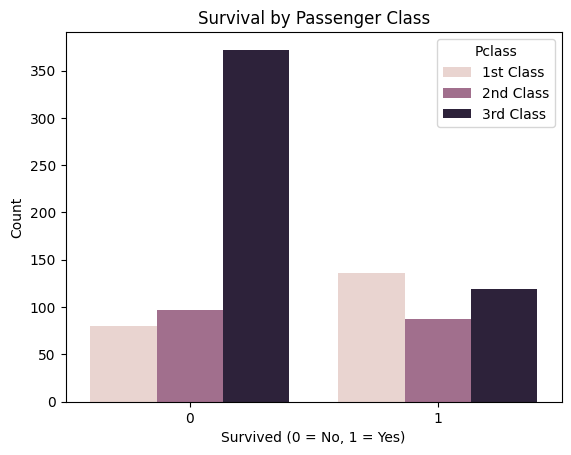

In [83]:
sns.countplot(x='Survived', hue='Pclass', data=df)
plt.title('Survival by Passenger Class')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.legend(title='Pclass', labels=['1st Class', '2nd Class', '3rd Class'])
plt.show()

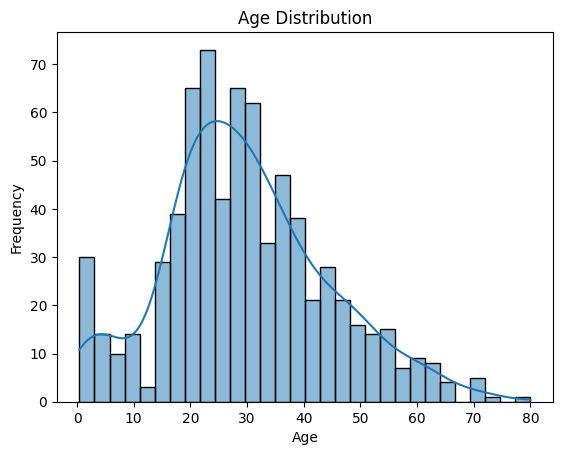

In [84]:
sns.histplot(df['Age'], kde=True, bins=30)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

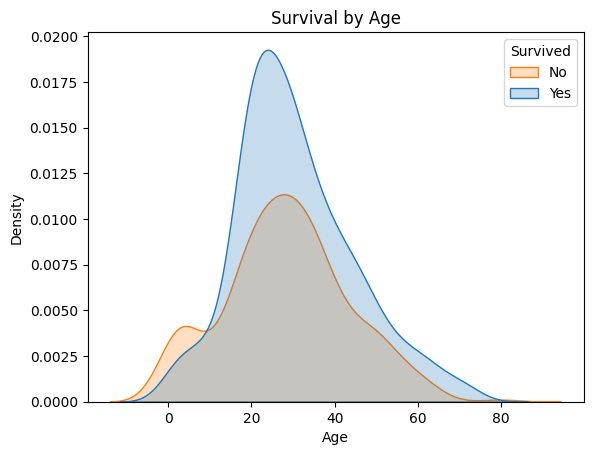

In [85]:
sns.kdeplot(data=df, x='Age', hue='Survived', fill=True)
plt.title('Survival by Age')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

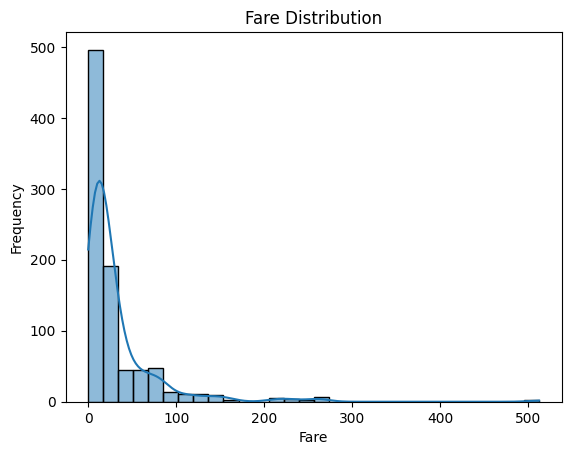

In [86]:
sns.histplot(df['Fare'], kde=True, bins=30)
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()

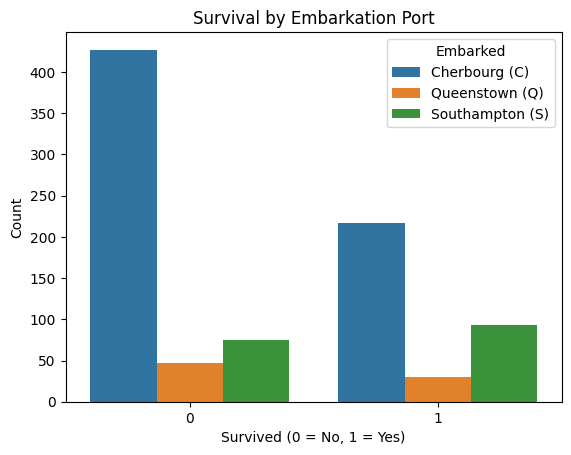

In [87]:
sns.countplot(x='Survived', hue='Embarked', data=df)
plt.title('Survival by Embarkation Port')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.legend(title='Embarked', labels=['Cherbourg (C)', 'Queenstown (Q)', 'Southampton (S)'])
plt.show()

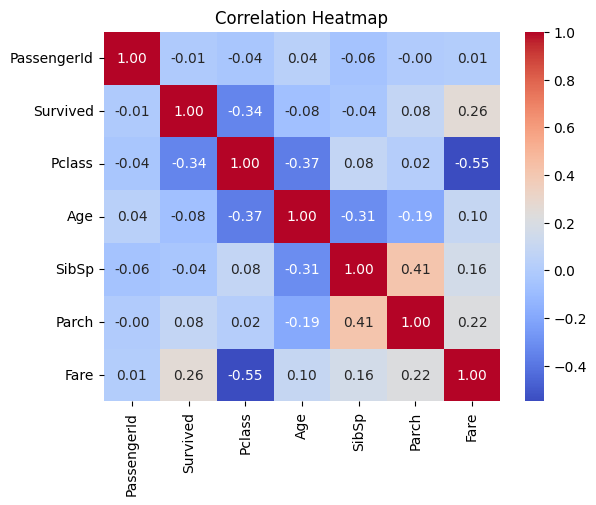

In [91]:
# Select only numerical columns
correlation_matrix = df.select_dtypes(include=['number']).corr()

# Plot the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [108]:
df ['Sex'] = df['Sex'].map({'male': 0 , 'female': 1})
print(df.head())

   PassengerId  Survived  Pclass                                               Name  Sex   Age  SibSp  Parch            Ticket     Fare Cabin Embarked
0            1         0       3                            Braund, Mr. Owen Harris    0  22.0      1      0         A/5 21171   7.2500   NaN        S
1            2         1       1  Cumings, Mrs. John Bradley (Florence Briggs Th...    1  38.0      1      0          PC 17599  71.2833   C85        C
2            3         1       3                             Heikkinen, Miss. Laina    1  26.0      0      0  STON/O2. 3101282   7.9250   NaN        S
3            4         1       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)    1  35.0      1      0            113803  53.1000  C123        S
4            5         0       3                           Allen, Mr. William Henry    0  35.0      0      0            373450   8.0500   NaN        S


In [109]:
# Extract titles from the 'Name' column
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Map rare titles to a common category
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')
df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

# Encode titles numerically
title_mapping = {'Mr': 1, 'Miss': 2, 'Mrs': 3, 'Master': 4, 'Rare': 5}
df['Title'] = df['Title'].map(title_mapping)

print(df[['Name', 'Title']].head())

                                                Name  Title
0                            Braund, Mr. Owen Harris      1
1  Cumings, Mrs. John Bradley (Florence Briggs Th...      3
2                             Heikkinen, Miss. Laina      2
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)      3
4                           Allen, Mr. William Henry      1


<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
/var/folders/yn/2lkq6t6d0ns6d9pql61jch8h0000gn/T/ipykernel_2269/2167908406.py:2: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [110]:
# Create FamilySize feature
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1  # Add 1 to include the passenger themselves

# Create IsAlone feature
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

print(df[['SibSp', 'Parch', 'FamilySize', 'IsAlone']].head())

   SibSp  Parch  FamilySize  IsAlone
0      1      0           2        0
1      1      0           2        0
2      0      0           1        1
3      1      0           2        0
4      0      0           1        1


In [111]:
# Fill missing Age values with the median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Bin ages into categories
df['AgeBin'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 80], labels=[0, 1, 2, 3, 4])

print(df[['Age', 'AgeBin']].head())

    Age AgeBin
0  22.0      2
1  38.0      3
2  26.0      2
3  35.0      2
4  35.0      2


In [112]:
# Fill missing Fare values with the median
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

# Bin fares into categories
df['FareBin'] = pd.qcut(df['Fare'], q=4, labels=[0, 1, 2, 3])

print(df[['Fare', 'FareBin']].head())

      Fare FareBin
0   7.2500       0
1  71.2833       3
2   7.9250       1
3  53.1000       3
4   8.0500       1


In [114]:
print(df.head())

   PassengerId  Survived  Pclass                                               Name  Sex   Age  SibSp  Parch            Ticket     Fare Cabin Embarked  Title  FamilySize  IsAlone AgeBin FareBin
0            1         0       3                            Braund, Mr. Owen Harris    0  22.0      1      0         A/5 21171   7.2500   NaN        S      1           2        0      2       0
1            2         1       1  Cumings, Mrs. John Bradley (Florence Briggs Th...    1  38.0      1      0          PC 17599  71.2833   C85        C      3           2        0      3       3
2            3         1       3                             Heikkinen, Miss. Laina    1  26.0      0      0  STON/O2. 3101282   7.9250   NaN        S      2           1        1      2       1
3            4         1       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)    1  35.0      1      0            113803  53.1000  C123        S      3           2        0      2       3
4            5         0      

In [115]:
df ['Embarked'] = df['Embarked'].map({'S': 0 , 'C': 1, 'Q': 2})
print(df.head())

   PassengerId  Survived  Pclass                                               Name  Sex   Age  SibSp  Parch            Ticket     Fare Cabin  Embarked  Title  FamilySize  IsAlone AgeBin FareBin
0            1         0       3                            Braund, Mr. Owen Harris    0  22.0      1      0         A/5 21171   7.2500   NaN       0.0      1           2        0      2       0
1            2         1       1  Cumings, Mrs. John Bradley (Florence Briggs Th...    1  38.0      1      0          PC 17599  71.2833   C85       1.0      3           2        0      3       3
2            3         1       3                             Heikkinen, Miss. Laina    1  26.0      0      0  STON/O2. 3101282   7.9250   NaN       0.0      2           1        1      2       1
3            4         1       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)    1  35.0      1      0            113803  53.1000  C123       0.0      3           2        0      2       3
4            5         0 

In [116]:
# Create FarePerPerson feature
df['FarePerPerson'] = df['Fare'] / df['FamilySize']

print(df[['Fare', 'FamilySize', 'FarePerPerson']].head())

      Fare  FamilySize  FarePerPerson
0   7.2500           2        3.62500
1  71.2833           2       35.64165
2   7.9250           1        7.92500
3  53.1000           2       26.55000
4   8.0500           1        8.05000


In [117]:
print(df.head())

   PassengerId  Survived  Pclass                                               Name  Sex   Age  SibSp  Parch            Ticket     Fare Cabin  Embarked  Title  FamilySize  IsAlone AgeBin FareBin  FarePerPerson
0            1         0       3                            Braund, Mr. Owen Harris    0  22.0      1      0         A/5 21171   7.2500   NaN       0.0      1           2        0      2       0        3.62500
1            2         1       1  Cumings, Mrs. John Bradley (Florence Briggs Th...    1  38.0      1      0          PC 17599  71.2833   C85       1.0      3           2        0      3       3       35.64165
2            3         1       3                             Heikkinen, Miss. Laina    1  26.0      0      0  STON/O2. 3101282   7.9250   NaN       0.0      2           1        1      2       1        7.92500
3            4         1       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)    1  35.0      1      0            113803  53.1000  C123       0.0      3  

In [118]:
# Drop unnecessary columns
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

print(df.head())

   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked  Title  FamilySize  IsAlone AgeBin FareBin  FarePerPerson
0         0       3    0  22.0      1      0   7.2500       0.0      1           2        0      2       0        3.62500
1         1       1    1  38.0      1      0  71.2833       1.0      3           2        0      3       3       35.64165
2         1       3    1  26.0      0      0   7.9250       0.0      2           1        1      2       1        7.92500
3         1       1    1  35.0      1      0  53.1000       0.0      3           2        0      2       3       26.55000
4         0       3    0  35.0      0      0   8.0500       0.0      1           1        1      2       1        8.05000


In [119]:
from sklearn.preprocessing import StandardScaler # Standardize features
scaler = StandardScaler()
df[['Age', 'Fare','FarePerPerson']] = scaler.fit_transform(df[['Age', 'Fare', 'FarePerPerson']])
print(df.head())

   Survived  Pclass  Sex       Age  SibSp  Parch      Fare  Embarked  Title  FamilySize  IsAlone AgeBin FareBin  FarePerPerson
0         0       3    0 -0.565736      1      0 -0.502445       0.0      1           2        0      2       0      -0.454798
1         1       1    1  0.663861      1      0  0.786845       1.0      3           2        0      3       3       0.438994
2         1       3    1 -0.258337      0      0 -0.488854       0.0      2           1        1      2       1      -0.334757
3         1       1    1  0.433312      1      0  0.420730       0.0      3           2        0      2       3       0.185187
4         0       3    0  0.433312      0      0 -0.486337       0.0      1           1        1      2       1      -0.331267


Survived         1.000000
Sex              0.543351
Title            0.407753
FareBin          0.299357
Fare             0.257307
FarePerPerson    0.221600
Embarked         0.108669
Parch            0.081629
FamilySize       0.016639
SibSp           -0.035322
Age             -0.064910
AgeBin          -0.093191
IsAlone         -0.203367
Pclass          -0.338481
Name: Survived, dtype: float64
Axes(0.125,0.11;0.775x0.77)


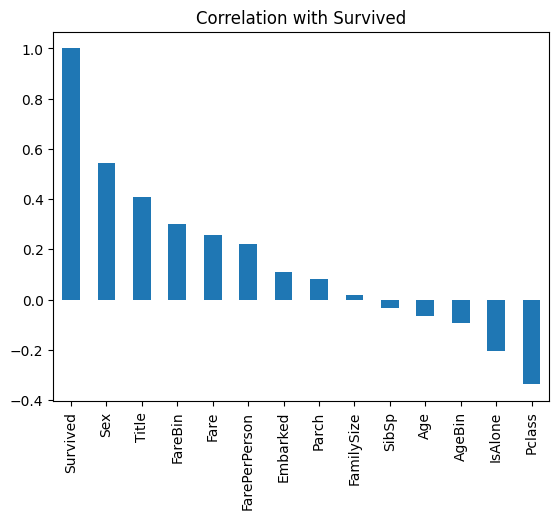

In [120]:
import matplotlib.pyplot as plt
print(df.corr()['Survived'].sort_values(ascending=False)) # correlation matrix
print(df.corr()['Survived'].sort_values(ascending=False).plot(kind='bar')) # correlation matrix plot
plt.title('Correlation with Survived')
plt.show()

In [14]:
df = df.drop(columns=['SibSp']) # drop since they are not needed anymore
print(df.head())

   Survived  Pclass  Sex       Age  Parch      Fare  Title  FamilySize  IsAlone AgeBin FareBin  Embarked_Q  Embarked_S  FarePerPerson
0         0       3    0 -0.565736      0 -0.502445      1           2        0      2       0           0           1      -0.454798
1         1       1    1  0.663861      0  0.786845      3           2        0      3       3           0           0       0.438994
2         1       3    1 -0.258337      0 -0.488854      2           1        1      2       1           0           1      -0.334757
3         1       1    1  0.433312      0  0.420730      3           2        0      2       3           0           1       0.185187
4         0       3    0  0.433312      0 -0.486337      1           1        1      2       1           0           1      -0.331267


In [42]:
df = df.drop(columns=['FamilySize', 'Embarked_Q']) # drop since they are not needed anymore
print(df.head())

   Survived  Pclass  Sex       Age  Parch      Fare  Title  IsAlone AgeBin FareBin  Embarked_S  FarePerPerson
0         0       3    0 -0.565736      0 -0.502445      1        0      2       0           1      -0.454798
1         1       1    1  0.663861      0  0.786845      3        0      3       3           0       0.438994
2         1       3    1 -0.258337      0 -0.488854      2        1      2       1           1      -0.334757
3         1       1    1  0.433312      0  0.420730      3        0      2       3           1       0.185187
4         0       3    0  0.433312      0 -0.486337      1        1      2       1           1      -0.331267


In [121]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Survived'])
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [122]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on the training data
rf_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_rf = rf_model.predict(X_test)

In [124]:
# Calculate accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy_rf)

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Print confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.8268156424581006
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.85       105
           1       0.79      0.80      0.79        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179

Confusion Matrix:
[[89 16]
 [15 59]]


In [125]:
# Feature importance
import pandas as pd
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Feature Importance:")
print(feature_importance)

Feature Importance:
          Feature  Importance
2             Age    0.172480
7           Title    0.168444
5            Fare    0.151896
12  FarePerPerson    0.141695
1             Sex    0.133279
0          Pclass    0.058731
8      FamilySize    0.043306
10         AgeBin    0.032659
11        FareBin    0.026854
6        Embarked    0.024182
3           SibSp    0.023274
4           Parch    0.016163
9         IsAlone    0.007038


In [126]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy:", scores.mean())

Cross-Validation Accuracy: 0.8103069487163392


In [172]:
print(df.head())

   Survived  Pclass  Sex       Age  SibSp  Parch      Fare  Embarked  Title  FamilySize  IsAlone AgeBin FareBin  FarePerPerson
0         0       3    0 -0.565736      1      0 -0.502445       0.0      1           2        0      2       0      -0.454798
1         1       1    1  0.663861      1      0  0.786845       1.0      3           2        0      3       3       0.438994
2         1       3    1 -0.258337      0      0 -0.488854       0.0      2           1        1      2       1      -0.334757
3         1       1    1  0.433312      1      0  0.420730       0.0      3           2        0      2       3       0.185187
4         0       3    0  0.433312      0      0 -0.486337       0.0      1           1        1      2       1      -0.331267


In [180]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [174]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_val)

# Evaluate the model
print("Decision Tree Accuracy:", accuracy_score(y_val, y_pred_dt))
print(classification_report(y_val, y_pred_dt))

Decision Tree Accuracy: 0.8100558659217877
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.71      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



In [175]:
print(X_train.isnull().sum())

Pclass           0
Sex              0
Age              0
SibSp            0
Parch            0
Fare             0
Embarked         2
Title            0
FamilySize       0
IsAlone          0
AgeBin           0
FareBin          0
FarePerPerson    0
dtype: int64


In [176]:
from sklearn.impute import SimpleImputer

# Initialize the imputer (fill missing values with the median)
imputer = SimpleImputer(strategy='median')

# Fit and transform the training data
X_train = imputer.fit_transform(X_train)

# Transform the validation data
X_val = imputer.transform(X_val)

In [177]:
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

# Make predictions
y_pred_gb = gb_model.predict(X_val)

# Evaluate the model
print("Gradient Boosting Accuracy:", accuracy_score(y_val, y_pred_gb))
print(classification_report(y_val, y_pred_gb))

Gradient Boosting Accuracy: 0.8044692737430168
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [178]:
from xgboost import XGBClassifier

# Initialize and train the XGBoost model
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred_xgb = xgb_model.predict(X_val)

# Evaluate the model
print("XGBoost Accuracy:", accuracy_score(y_val, y_pred_xgb))
print(classification_report(y_val, y_pred_xgb))

XGBoost Accuracy: 0.8324022346368715
              precision    recall  f1-score   support

           0       0.86      0.87      0.86       110
           1       0.79      0.77      0.78        69

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



/Users/I522775/Library/Python/3.12/lib/python/site-packages/xgboost/training.py:183: UserWarning: [16:30:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
import joblib

# Save the model
joblib.dump(xgb_model, 'xgboost_model.pkl')



In [ ]:
# Load the Optuna-tuned XGBoost model
xgb_model_loaded = joblib.load('xgboost_optuna_model.pkl')
print("Optuna-tuned XGBoost model loaded successfully")

In [157]:
df_test = pd.read_csv('test.csv')
print(df_test.columns)

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [158]:
df_test['Sex'] = df_test['Sex'].map({'male': 0 , 'female': 1})
print(df_test.head())

   PassengerId  Pclass                                          Name  Sex   Age  SibSp  Parch   Ticket     Fare Cabin Embarked
0          892       3                              Kelly, Mr. James    0  34.5      0      0   330911   7.8292   NaN        Q
1          893       3              Wilkes, Mrs. James (Ellen Needs)    1  47.0      1      0   363272   7.0000   NaN        S
2          894       2                     Myles, Mr. Thomas Francis    0  62.0      0      0   240276   9.6875   NaN        Q
3          895       3                              Wirz, Mr. Albert    0  27.0      0      0   315154   8.6625   NaN        S
4          896       3  Hirvonen, Mrs. Alexander (Helga E Lindqvist)    1  22.0      1      1  3101298  12.2875   NaN        S


In [159]:
df_test ['Embarked'] = df_test['Embarked'].map({'S': 0 , 'C': 1, 'Q': 2})
print(df_test.head())

   PassengerId  Pclass                                          Name  Sex   Age  SibSp  Parch   Ticket     Fare Cabin  Embarked
0          892       3                              Kelly, Mr. James    0  34.5      0      0   330911   7.8292   NaN         2
1          893       3              Wilkes, Mrs. James (Ellen Needs)    1  47.0      1      0   363272   7.0000   NaN         0
2          894       2                     Myles, Mr. Thomas Francis    0  62.0      0      0   240276   9.6875   NaN         2
3          895       3                              Wirz, Mr. Albert    0  27.0      0      0   315154   8.6625   NaN         0
4          896       3  Hirvonen, Mrs. Alexander (Helga E Lindqvist)    1  22.0      1      1  3101298  12.2875   NaN         0


In [160]:
# Fill missing values in 'Age' with the median from the training dataset
df_test['Age'] = df_test['Age'].fillna(df['Age'].median())

# Fill missing values in 'Fare' with the median from the training dataset
df_test['Fare'] = df_test['Fare'].fillna(df['Fare'].median())

In [161]:
# Extract 'Title' from the 'Name' column
df_test['Title'] = df_test['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
df_test['Title'] = df_test['Title'].replace(['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df_test['Title'] = df_test['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
title_mapping = {'Mr': 1, 'Miss': 2, 'Mrs': 3, 'Master': 4, 'Rare': 5}
df_test['Title'] = df_test['Title'].map(title_mapping)

# Create 'FamilySize' feature
df_test['FamilySize'] = df_test['SibSp'] + df_test['Parch'] + 1

# Create 'IsAlone' feature
df_test['IsAlone'] = (df_test['FamilySize'] == 1).astype(int)

<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
/var/folders/yn/2lkq6t6d0ns6d9pql61jch8h0000gn/T/ipykernel_2269/681267534.py:2: SyntaxWarning: invalid escape sequence '\.'
  df_test['Title'] = df_test['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [164]:
# Bin 'Age' into categories
df_test['AgeBin'] = pd.cut(df_test['Age'], bins=[0, 12, 18, 35, 60, 80], labels=[0, 1, 2, 3, 4])

# Bin 'Fare' into quartiles
df_test['FareBin'] = pd.qcut(df_test['Fare'], q=4, labels=[0, 1, 2, 3])

In [163]:
# Create 'FarePerPerson' feature
df_test['FarePerPerson'] = df_test['Fare'] / df_test['FamilySize']

# Standardize 'Age', 'Fare', and 'FarePerPerson'
df_test[['Age', 'Fare', 'FarePerPerson']] = scaler.transform(df_test[['Age', 'Fare', 'FarePerPerson']])

In [165]:
print(df.head())

   Survived  Pclass  Sex       Age  SibSp  Parch      Fare  Embarked  Title  FamilySize  IsAlone AgeBin FareBin  FarePerPerson
0         0       3    0 -0.565736      1      0 -0.502445       0.0      1           2        0      2       0      -0.454798
1         1       1    1  0.663861      1      0  0.786845       1.0      3           2        0      3       3       0.438994
2         1       3    1 -0.258337      0      0 -0.488854       0.0      2           1        1      2       1      -0.334757
3         1       1    1  0.433312      1      0  0.420730       0.0      3           2        0      2       3       0.185187
4         0       3    0  0.433312      0      0 -0.486337       0.0      1           1        1      2       1      -0.331267


In [168]:
print(df_test.head())

   PassengerId  Pclass                                          Name  Sex       Age  SibSp  Parch   Ticket      Fare Cabin  Embarked  Title  FamilySize  IsAlone AgeBin FareBin  FarePerPerson
0          892       3                              Kelly, Mr. James    0  0.394887      0      0   330911 -0.490783   NaN         2      1           1        1      0       0      -0.337431
1          893       3              Wilkes, Mrs. James (Ellen Needs)    1  1.355510      1      0   363272 -0.507479   NaN         0      3           2        0      0       0      -0.458287
2          894       2                     Myles, Mr. Thomas Francis    0  2.508257      0      0   240276 -0.453367   NaN         2      1           1        1      0       1      -0.285554
3          895       3                              Wirz, Mr. Albert    0 -0.181487      0      0   315154 -0.474005   NaN         0      1           1        1    NaN       1      -0.314169
4          896       3  Hirvonen, Mrs. Alexan

In [170]:
import pandas as pd

# Convert X_train back to a DataFrame
X_train = pd.DataFrame(X_train, columns=df.drop(columns=['Survived']).columns)

# Convert X_val back to a DataFrame (if applicable)
X_val = pd.DataFrame(X_val, columns=df.drop(columns=['Survived']).columns)

# Now you can print the columns
print("Training dataset columns:", X_train.columns.tolist())
print("Test dataset columns:", df_test.columns.tolist())

Training dataset columns: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'AgeBin', 'FareBin', 'FarePerPerson']
Test dataset columns: ['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'AgeBin', 'FareBin', 'FarePerPerson']


In [171]:
# Drop unnecessary columns
df_test_processed = df_test.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

# Ensure test dataset has the same columns as the training dataset
df_test_processed = df_test_processed.reindex(columns=X_train.columns, fill_value=0)

# Make predictions using the XGBoost model
predictions = xgb_model.predict(df_test_processed)

# Create the submission file
submission = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],  # Use the original PassengerId column
    'Survived': predictions
})
submission.to_csv('submission.csv', index=False)

print("Submission file created: submission.csv")

Submission file created: submission.csv


In [139]:
# Drop unnecessary columns
df_test_processed = df_test.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

# Ensure test dataset has the same columns as the training dataset
df_test_processed = df_test_processed.reindex(columns=X_train.columns, fill_value=0)

# Make predictions
predictions = rf_model.predict(df_test_processed)

# Create the submission file
submission = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],  # Use the original PassengerId column
    'Survived': predictions
})
submission.to_csv('submission.csv', index=False)

print("Submission file created: submission.csv")

Submission file created: submission.csv


In [ ]:
df_test_processed = df_test_processed.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp', 'FamilySize'])

In [ ]:
df_test_processed = df_test_processed